In [74]:
# LVDT_simulation/tests/demo.ipynb
import sys
sys.path.append('../../')
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint
from core import data_handler
from utils.vc_analyser import VC_Calculator, VC_Analyser


## 1 simulation: offset comparison

#### 1.1 LVDT Simulation: 8mm vs 7.6mm offset comparison

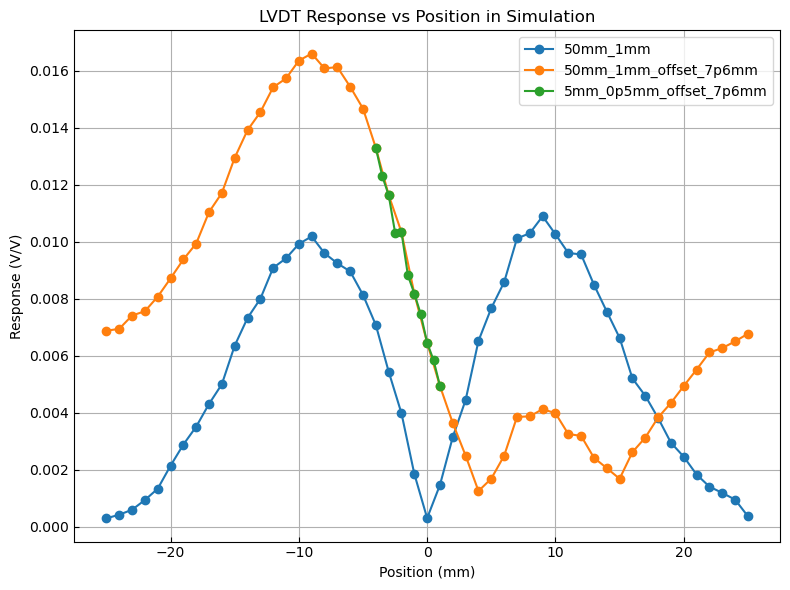

In [82]:
filenames =[
    "../data/prototype_validation/lvdt/lvdt_simulation_alucoil_50mm_1mm.h5",
    "../data/prototype_validation/lvdt/lvdt_simulation_alucoil_50mm_1mm_offset_7p6mm.h5",
    "../data/prototype_validation/lvdt/lvdt_simulation_alucoil_5mm_0p5mm_offset_7p6mm.h5",
]
plt.figure(figsize=(8,6))
for filename in filenames:            
    
    data_dict = data_handler.load_data(filename)
    config_data = data_handler.get_config_data(data_dict)
    volt_data = data_handler.get_lvdt_data(data_dict, data_type='voltage', flip_sign=False)
    curr_data = data_handler.get_lvdt_data(data_dict, data_type='current')

    position = volt_data['position']
    pickup_voltage = volt_data['Middle_Coil']['voltage_abs']
    excitation_voltage = (abs(volt_data['Upper_Coil']['voltage_abs']*2))
    excitation_current = np.mean(curr_data['Upper_Coil']['current_abs'])

    norm_voltage_volt = pickup_voltage / excitation_voltage
    norm_voltage_curr = pickup_voltage / excitation_current

    legend_label = filename.split('alucoil_')[-1].split('.')[0]
    plt.plot(position, norm_voltage_volt, marker = 'o', label = legend_label)
    plt.xlabel('Position (mm)')
    plt.ylabel('Response (V/V)')
    plt.tick_params(direction='in')
    plt.title('LVDT Response vs Position in Simulation')
    plt.grid()
    plt.legend()
plt.tight_layout()
plt.savefig("../result/1.alucoil_lvdt_response_simulation.pdf", dpi=300)


#### 1.2 VC Simulation: 8mm vs 7.6mm offset comparison

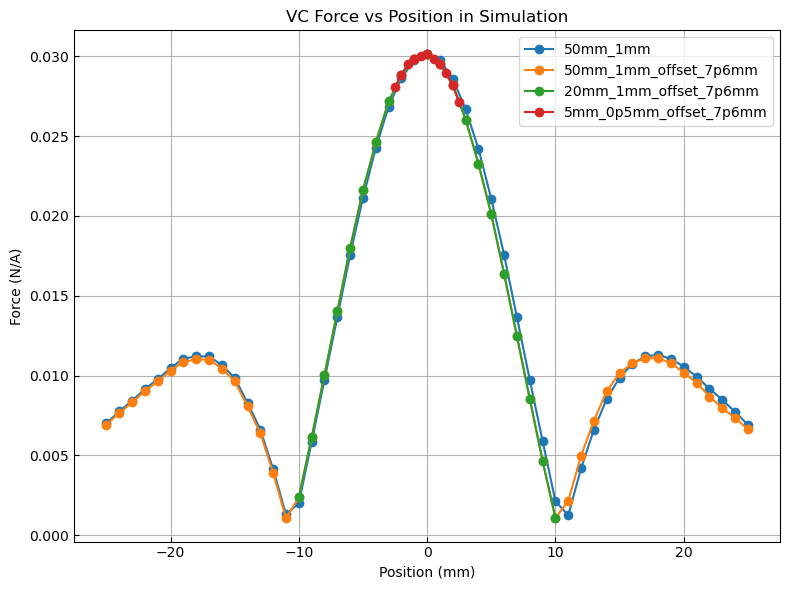

In [83]:
filenames = [
    '../data/prototype_validation/vc/vc_simulation_alucoil_50mm_1mm.h5',
    '../data/prototype_validation/vc/vc_simulation_alucoil_50mm_1mm_offset_7p6mm.h5',
    '../data/prototype_validation/vc/vc_simulation_alucoil_20mm_1mm_offset_7p6mm.h5',
    '../data/prototype_validation/vc/vc_simulation_alucoil_5mm_0p5mm_offset_7p6mm.h5',
    ]


plt.figure(figsize=(8,6))

for filename in filenames:
    data_dict = data_handler.load_data(filename)
    config_data = data_handler.get_config_data(data_dict)
    vc_data = data_handler.get_vc_data(data_dict)
    position = vc_data['position']
    dri_current = config_data['coils']['Upper_Coil']['circuit_current']
    force = abs(vc_data['Lower_Coil']['force']+vc_data['Upper_Coil']['force'])
    norm_force = np.array(force)/dri_current
    max_norm_force = max(norm_force)
    fvi = ((1 - force )/ max_norm_force) * 100
    legend_label = filename.split('alucoil_')[-1].split('.')[0]
    
    plt.plot(position, norm_force, marker = "o", label= legend_label)
    plt.xlabel('Position (mm)')
    plt.ylabel('Force (N/A)')
    plt.tick_params(direction='in')
    plt.title('VC Force vs Position in Simulation')
    plt.grid(True)
    plt.legend()
plt.tight_layout()
plt.savefig("../result/2.alucoil_vc_response_simulation.pdf", dpi=300)


## 2 Measurement and Simulation: basic comparison

#### 2.1 LVDT comparison

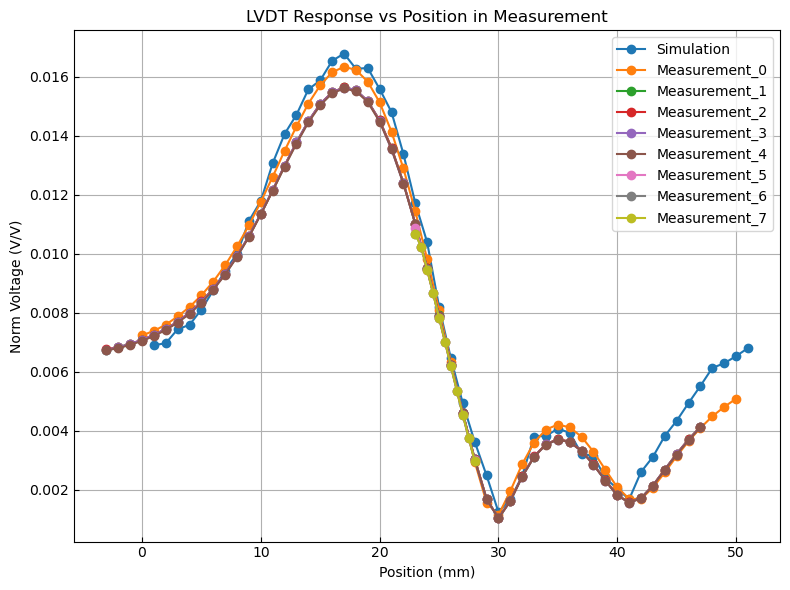

In [84]:
sim_file = "../data/prototype_validation/lvdt/lvdt_simulation_alucoil_50mm_1mm_offset_7p6mm.h5"

data_dict = data_handler.load_data(sim_file)
lvdt_data = data_handler.get_lvdt_data(data_dict, data_type='voltage' ,flip_sign=False)

sim_pos = np.array(lvdt_data['position']) + 26
sim_input_volt = np.mean(abs(lvdt_data['Lower_Coil']['voltage_abs']))*2 # sum of two excitation coils
sim_pickup_volt = np.array(lvdt_data['Middle_Coil']['voltage_abs'])
sim_pickup_volt_norm = (sim_pickup_volt / sim_input_volt) 

plt.figure(figsize=(8,6))
plt.plot(sim_pos, sim_pickup_volt_norm, label='Simulation', marker = 'o')
plt.xlabel('Position (mm)')
plt.ylabel('Norm Voltage (V/V)')
plt.tick_params(direction='in')
plt.title('LVDT Response vs Position in Measurement')
plt.grid(True)

exp_files = [
    '../data/prototype_validation/lvdt/lvdt_measurement_alucoil_50mm_1mm_01_1p07V.h5',
    '../data/prototype_validation/lvdt/lvdt_measurement_alucoil_50mm_1mm_11_1p05V.h5',
    '../data/prototype_validation/lvdt/lvdt_measurement_alucoil_50mm_1mm_12_1p05V.h5',
    '../data/prototype_validation/lvdt/lvdt_measurement_alucoil_50mm_1mm_13_1p08V.h5',
    '../data/prototype_validation/lvdt/lvdt_measurement_alucoil_50mm_1mm_14_1p17V.h5',
    '../data/prototype_validation/lvdt/lvdt_measurement_alucoil_5mm_0p5mm_01_1p08V.h5',
    '../data/prototype_validation/lvdt/lvdt_measurement_alucoil_5mm_0p5mm_02_1p08V.h5',
    '../data/prototype_validation/lvdt/lvdt_measurement_alucoil_5mm_0p5mm_03_1p08V.h5',
]
for i, file in enumerate(exp_files):
    f = h5py.File(file, 'r')
    exp_pos = np.array(f['PI'][:])
    exp_pickup_amp = np.array(f['Fit_Amp'][:])
    exp_input_waveform = np.array(f['excitation'][:])
    exp_pickup_waveform = np.array(f['pick-up'][:])

    exp_input_volt = np.mean([np.std(x)*np.sqrt(2) for x in exp_input_waveform]) # it is already the readout from two excitation coils
    exp_pickup_volt = np.array([np.std(x)*np.sqrt(2) for x in exp_pickup_waveform])
    exp_pickup_volt_norm = (exp_pickup_volt / exp_input_volt)
    if i != 0:
        exp_pos = exp_pos -3
        exp_pickup_volt_norm = exp_pickup_volt_norm 
    
    plt.plot(exp_pos, exp_pickup_volt_norm, marker = 'o', label=f'Measurement_{i}')

plt.legend()
plt.tight_layout()
plt.savefig("../result/3.alucoil_lvdt_response_measurement.pdf", dpi=300)

#### 2.2 VC comparison

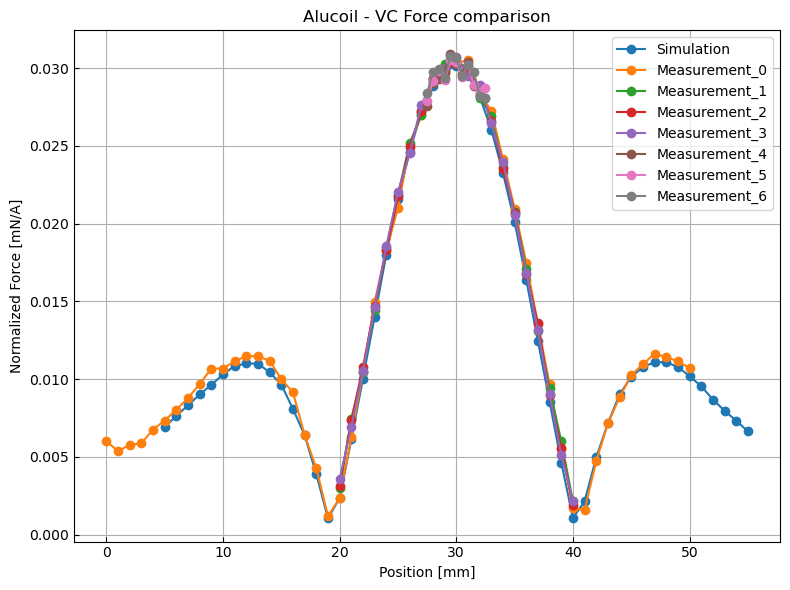

In [85]:
# simulation data
sim_filename = "../data/prototype_validation/vc/vc_simulation_alucoil_50mm_1mm_offset_7p6mm.h5"

sim_data_dict = data_handler.load_data(sim_filename)
sim_config_data = data_handler.get_config_data(sim_data_dict)
sim_vc_data = data_handler.get_vc_data(sim_data_dict)

sim_position = sim_vc_data['position']+30
dri_current = config_data['coils']['Upper_Coil']['circuit_current']
sim_force = abs((sim_vc_data['Lower_Coil']['force'])+(sim_vc_data['Upper_Coil']['force']))
sim_norm_force = np.array(sim_force)/dri_current
sim_max_norm_force = max(sim_norm_force)
sim_fvi = ((1 - sim_norm_force )/ sim_max_norm_force) * 100

# measurement data
exp_filenames = [
    "../data/prototype_validation/vc/vc_measurement_alucoil_50mm_1mm_01.h5",
    "../data/prototype_validation/vc/vc_measurement_alucoil_20mm_1mm_01.h5",
    "../data/prototype_validation/vc/vc_measurement_alucoil_20mm_1mm_02.h5",
    "../data/prototype_validation/vc/vc_measurement_alucoil_20mm_1mm_03.h5",
    "../data/prototype_validation/vc/vc_measurement_alucoil_5mm_0p5mm_11.h5",
    "../data/prototype_validation/vc/vc_measurement_alucoil_5mm_0p5mm_12.h5",
    "../data/prototype_validation/vc/vc_measurement_alucoil_5mm_0p5mm_13.h5",
]

plt.figure(figsize=(8,6))
plt.plot(sim_position, sim_norm_force, label='Simulation', marker = 'o')
plt.xlabel('Position [mm]')
plt.ylabel('Normalized Force [mN/A]')
plt.tick_params(direction='in')
plt.grid(True)
plt.title('Alucoil - VC Force comparison')

for i, exp_filename in enumerate(exp_filenames):
    vc_calculator = VC_Calculator()
    exp_data_dict, curr = vc_calculator.force_calculation(exp_filename, norm=True)
    exp_data_sorted = sorted(exp_data_dict.items(), key = lambda item: float(item[0]))
    exp_position = []
    exp_norm_force = []
    for item in exp_data_sorted:
        exp_position.append(float(item[0]))
        exp_norm_force.append(item[1])
    exp_position = np.array(exp_position)
    exp_norm_force = np.array(exp_norm_force)

    plt.plot(exp_position, exp_norm_force, label=f'Measurement_{i}', marker = 'o')
    
plt.legend()
plt.tight_layout()
plt.savefig("../result/4.alucoil_vc_response_measurement.pdf", dpi=300)

## 3 Measurement and Simulation: Fit comparison

#### 3.1 LVDT response comparison: 5mm range

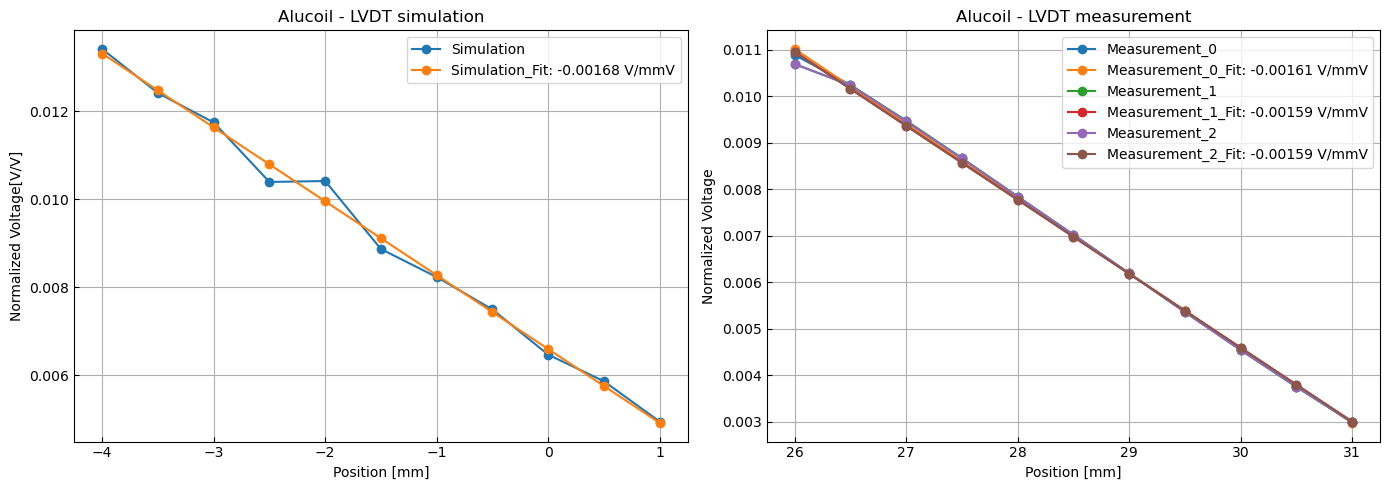

In [86]:
# simulation data
sim_file = "../data/prototype_validation/lvdt/lvdt_simulation_alucoil_5mm_0p5mm_offset_7p6mm.h5"
data_dict = data_handler.load_data(sim_file)
lvdt_data = data_handler.get_lvdt_data(data_dict, data_type='voltage' ,flip_sign=False)
sim_pos = np.array(lvdt_data['position'])
sim_input_volt = np.mean(abs(lvdt_data['Lower_Coil']['voltage_abs']))*2 # sum of two excitation coils
sim_pickup_volt = np.array(lvdt_data['Middle_Coil']['voltage_abs'])
sim_pickup_volt_norm = (sim_pickup_volt / sim_input_volt)#[::-1]
sim_fit_data = data_handler.linear_analysis_FS(sim_pos,sim_pickup_volt_norm)

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(sim_pos, sim_pickup_volt_norm, label='Simulation', marker = 'o')
plt.plot(sim_pos, sim_fit_data['predict'], 
            label=f'Simulation_Fit: {sim_fit_data['response']['slope']:.5f} V/mmV', marker = 'o')
plt.xlabel('Position [mm]')
plt.ylabel('Normalized Voltage[V/V]')
plt.title('Alucoil - LVDT simulation')
plt.tick_params(direction='in')
plt.grid(True)
plt.legend()

# measurement datas
exp_files = [
    '../data/prototype_validation/lvdt/lvdt_measurement_alucoil_5mm_0p5mm_01_1p08V.h5',
    '../data/prototype_validation/lvdt/lvdt_measurement_alucoil_5mm_0p5mm_02_1p08V.h5',
    '../data/prototype_validation/lvdt/lvdt_measurement_alucoil_5mm_0p5mm_03_1p08V.h5',
]

plt.subplot(1,2,2)
for i, exp_file in enumerate(exp_files):
    f = h5py.File(exp_file, 'r')
    exp_pos = np.array(f['PI'][:])
    exp_pickup_amp = np.array(f['Fit_Amp'][:])
    exp_input_waveform = np.array(f['excitation'][:])
    exp_pickup_waveform = np.array(f['pick-up'][:])
    exp_input_volt = np.mean([np.std(x)*np.sqrt(2) for x in exp_input_waveform]) # it is already the readout from two excitation coils
    exp_pickup_volt = np.array([np.std(x)*np.sqrt(2) for x in exp_pickup_waveform])
    exp_pickup_volt_norm = (exp_pickup_volt / exp_input_volt) #[::-1]
    exp_fit_data = data_handler.linear_analysis_FS(exp_pos,exp_pickup_volt_norm)

    plt.plot(exp_pos, exp_pickup_volt_norm, label = f'Measurement_{i}', marker = 'o')
    plt.plot(exp_pos, exp_fit_data['predict'], 
            label = f'Measurement_{i}_Fit: {exp_fit_data['response']['slope']:.5f} V/mmV', marker = 'o')
   
plt.xlabel('Position [mm]')
plt.ylabel('Normalized Voltage')
plt.title('Alucoil - LVDT measurement')
plt.tick_params(direction='in')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("../result/5.alucoil_lvdt_response_fit_comparison_5mm.pdf", dpi=300)

#### 3.2 VC force comparison: 20mm + 5mm

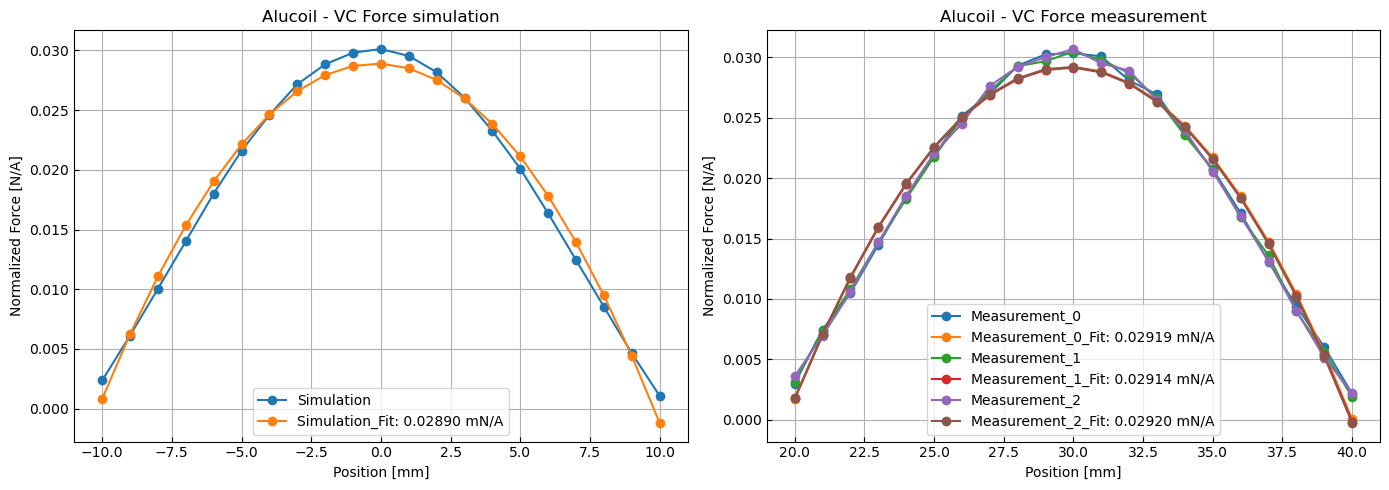

In [87]:
# simulation data
sim_filename = "../data/prototype_validation/vc/vc_simulation_alucoil_20mm_1mm_offset_7p6mm.h5"

sim_data_dict = data_handler.load_data(sim_filename)
sim_config_data = data_handler.get_config_data(sim_data_dict)
sim_vc_data = data_handler.get_vc_data(sim_data_dict)

sim_position = sim_vc_data['position']
dri_current = config_data['coils']['Upper_Coil']['circuit_current']
sim_force = abs((sim_vc_data['Lower_Coil']['force'])+(sim_vc_data['Upper_Coil']['force']))
sim_norm_force = np.array(sim_force)/dri_current

sim_fit_data = data_handler.quadratic_analysis(sim_position, sim_norm_force)

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(sim_position, sim_norm_force, label='Simulation', marker = 'o')
plt.plot(sim_position, sim_fit_data['predict'], label=f'Simulation_Fit: {sim_fit_data['max_force']:.5f} mN/A', marker = 'o')
plt.xlabel('Position [mm]')
plt.ylabel('Normalized Force [N/A]')
plt.title('Alucoil - VC Force simulation')
plt.tick_params(direction='in')
plt.grid(True)
plt.legend(loc = 'lower center')
# measurement data
exp_filenames = [

    "../data/prototype_validation/vc/vc_measurement_alucoil_20mm_1mm_01.h5",
    "../data/prototype_validation/vc/vc_measurement_alucoil_20mm_1mm_02.h5",
    "../data/prototype_validation/vc/vc_measurement_alucoil_20mm_1mm_03.h5",
]

plt.subplot(1,2,2)
for i, exp_filename in enumerate(exp_filenames):
    vc_calculator = VC_Calculator()
    exp_data_dict, curr = vc_calculator.force_calculation(exp_filename, norm=True)
    exp_data_sorted = sorted(exp_data_dict.items(), key = lambda item: float(item[0]))
    exp_position = []
    exp_norm_force = []
    for item in exp_data_sorted:
        exp_position.append(float(item[0]))
        exp_norm_force.append(item[1])
    exp_position = np.array(exp_position)
    exp_norm_force = np.array(exp_norm_force)
    exp_fit_data = data_handler.quadratic_analysis(exp_position, exp_norm_force)

    plt.plot(exp_position, exp_norm_force, label=f'Measurement_{i}', marker = 'o')
    plt.plot(exp_position, exp_fit_data['predict'], label=f'Measurement_{i}_Fit: {exp_fit_data['max_force']:.5f} mN/A', marker = 'o')
    
plt.xlabel('Position [mm]')
plt.ylabel('Normalized Force [N/A]')
plt.title('Alucoil - VC Force measurement')
plt.tick_params(direction='in')
plt.grid(True)
plt.legend(loc = 'lower center')
plt.tight_layout()
plt.savefig("../result/6.alucoil_vc_response_fit_comparison_20mm.pdf", dpi=300)
    


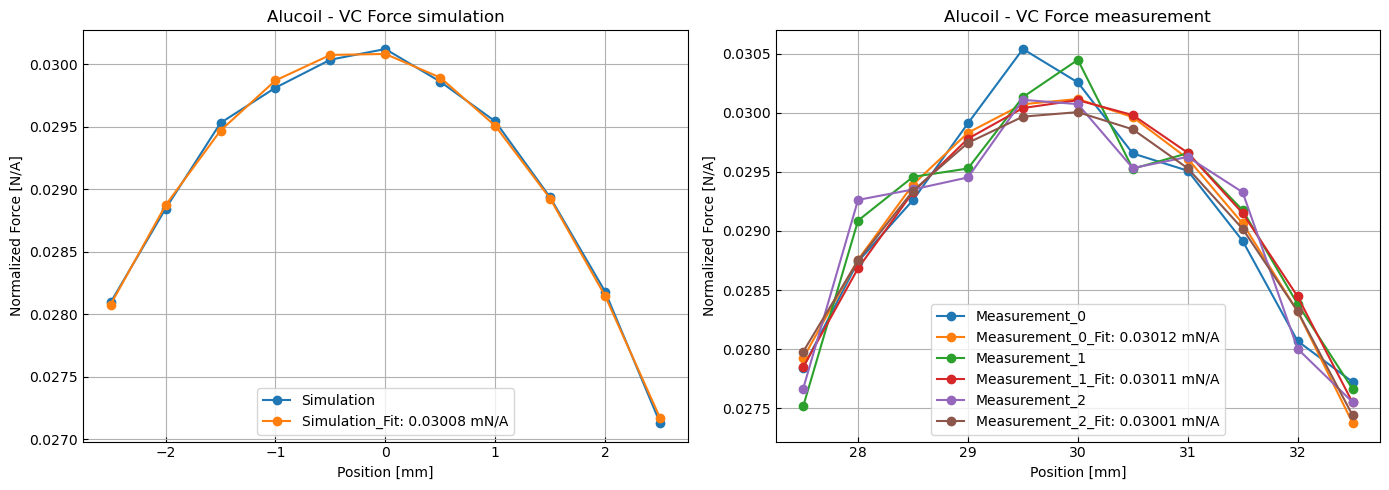

In [88]:
# simulation data
sim_filename = "../data/prototype_validation/vc/vc_simulation_alucoil_5mm_0p5mm_offset_7p6mm.h5"

sim_data_dict = data_handler.load_data(sim_filename)
sim_config_data = data_handler.get_config_data(sim_data_dict)
sim_vc_data = data_handler.get_vc_data(sim_data_dict)

sim_position = sim_vc_data['position']
dri_current = config_data['coils']['Upper_Coil']['circuit_current']
sim_force = abs((sim_vc_data['Lower_Coil']['force'])+(sim_vc_data['Upper_Coil']['force']))
sim_norm_force = np.array(sim_force)/dri_current

sim_fit_data = data_handler.quadratic_analysis(sim_position, sim_norm_force)

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(sim_position, sim_norm_force, label='Simulation', marker = 'o')
plt.plot(sim_position, sim_fit_data['predict'], label=f'Simulation_Fit: {sim_fit_data['max_force']:.5f} mN/A', marker = 'o')
plt.xlabel('Position [mm]')
plt.ylabel('Normalized Force [N/A]')
plt.title('Alucoil - VC Force simulation')
plt.tick_params(direction='in')
plt.grid(True)
plt.legend(loc = 'lower center')
# measurement data
exp_filenames = [
    "../data/prototype_validation/vc/vc_measurement_alucoil_5mm_0p5mm_11.h5",
    "../data/prototype_validation/vc/vc_measurement_alucoil_5mm_0p5mm_12.h5",
    "../data/prototype_validation/vc/vc_measurement_alucoil_5mm_0p5mm_13.h5",
]

plt.subplot(1,2,2)
for i, exp_filename in enumerate(exp_filenames):
    vc_calculator = VC_Calculator()
    exp_data_dict, curr = vc_calculator.force_calculation(exp_filename, norm=True, method='fit')
    exp_data_sorted = sorted(exp_data_dict.items(), key = lambda item: float(item[0]))
    exp_position = []
    exp_norm_force = []
    for item in exp_data_sorted:
        exp_position.append(float(item[0]))
        exp_norm_force.append(item[1])
    exp_position = np.array(exp_position)
    exp_norm_force = np.array(exp_norm_force)
    exp_fit_data = data_handler.quadratic_analysis(exp_position, exp_norm_force)

    plt.plot(exp_position, exp_norm_force, label=f'Measurement_{i}', marker = 'o')
    plt.plot(exp_position, exp_fit_data['predict'], label=f'Measurement_{i}_Fit: {exp_fit_data['max_force']:.5f} mN/A', marker = 'o')
    
plt.xlabel('Position [mm]')
plt.ylabel('Normalized Force [N/A]')
plt.title('Alucoil - VC Force measurement')
plt.tick_params(direction='in')
plt.grid(True)
plt.legend(loc = 'lower center')
plt.tight_layout()
plt.savefig("../result/7.alucoil_vc_response_fit_comparison_5mm.pdf", dpi=300)


## Archive: lvdt response 50 mm fit comparison

In [ ]:
# measurement datas
exp_files = [
    '../data/prototype_validation/lvdt/lvdt_measurement_alucoil_50mm_1mm_01_1p07V.h5',
    '../data/prototype_validation/lvdt/lvdt_measurement_alucoil_50mm_1mm_11_1p05V.h5'
]

for exp_file in exp_files:
    f = h5py.File(exp_file, 'r')
    exp_pos = np.array(f['PI'][:])
    exp_pickup_amp = np.array(f['Fit_Amp'][:])
    exp_input_waveform = np.array(f['excitation'][:])
    exp_pickup_waveform = np.array(f['pick-up'][:])
    exp_input_volt = np.mean([np.std(x)*np.sqrt(2) for x in exp_input_waveform]) # it is already the readout from two excitation coils
    exp_pickup_volt = np.array([np.std(x)*np.sqrt(2) for x in exp_pickup_waveform])
    exp_pickup_volt_norm = (exp_pickup_volt / exp_input_volt)
    exp_fit_data = data_handler.linear_analysis_FS(exp_pos[21:29],exp_pickup_volt_norm[21:29])

    # simulation data
    sim_file = "../data/prototype_validation/lvdt/lvdt_simulation_alucoil_50mm_1mm_offset_7p6mm.h5"
    data_dict = data_handler.load_data(sim_file)
    lvdt_data = data_handler.get_lvdt_data(data_dict, data_type='voltage' ,flip_sign=False)
    sim_pos = lvdt_data['position']
    sim_input_volt = np.mean(abs(lvdt_data['Lower_Coil']['voltage_abs']))*2 # sum of two excitation coils
    sim_pickup_volt = np.array(lvdt_data['Middle_Coil']['voltage_abs'])
    sim_pickup_volt_norm = (sim_pickup_volt / sim_input_volt) 
    sim_fit_data = data_handler.linear_analysis_FS(sim_pos[21:29],sim_pickup_volt_norm[21:29])

    plt.figure(figsize=(8,6))
    plt.plot(exp_pos, exp_pickup_volt_norm, label='Measurement', marker = 'o')
    plt.plot(sim_pos, sim_pickup_volt_norm, label='Simulation', marker = 'o')
    plt.xlabel('Position [mm]')
    plt.ylabel('Normalized Voltage')
    plt.tick_params(direction='in')
    plt.grid(True)
    plt.legend()
    plt.title('Alucoil - LVDT comparison')
    plt.tight_layout()

    plt.figure(figsize=(8,6))
    plt.plot(exp_pos[21:29], exp_fit_data['predict'], 
            label = f'Measurement Fit: {exp_fit_data['response']['slope']:.5f} V/mmV', marker = 'o')
    plt.plot(sim_pos[21:29], sim_fit_data['predict'],
                label=f'Simulation FIt: {sim_fit_data['response']['slope']:.5f} V/mmV', marker = 'o')
    plt.xlabel('Position [mm]')
    plt.ylabel('Normalized Voltage')
    plt.tick_params(direction='in')
    plt.grid(True)
    plt.legend()
    plt.title('Alucoil - LVDT comparison')
    plt.tight_layout()
